In [1]:
import numpy as np
import pandas as pd
import sys
import logging
logging.getLogger('tensorflow').disabled = True
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from MultiDepthRandomForest import MultiDepthRandomForestClassifier, MultiDepthNeuralRandomForestClassifier
from Dataset import import_accelerometer, import_vehicles, import_vowel, import_satellite, import_shuttle, import_sonar
import tensorflow as tf
from sklearn.metrics import roc_auc_score
import seaborn as sns
from  matplotlib.colors import LinearSegmentedColormap
tfk = tf.keras
tfkl = tfk.layers

2024-12-23 13:19:00.066127: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [9]:
X_sets, Y_sets = import_shuttle([0.35,0.35,0.1,0.2])
X_train = X_sets[0]
X_train_nn = X_sets[1]
X_val = X_sets[2]
X_test = X_sets[3]
Y_train = Y_sets[0]
Y_train_nn = Y_sets[1]
Y_val = Y_sets[2]
Y_test = Y_sets[3]
X_train_agg = np.vstack([X_train,X_train_nn])
Y_train_agg = np.concatenate([Y_train,Y_train_nn])

In [5]:
X_train.shape, X_train_nn.shape, X_val.shape, X_test.shape, X_train_agg.shape, Y_train.shape, Y_train_nn.shape, Y_val.shape, Y_test.shape, Y_train_agg.shape

((676, 18),
 (677, 18),
 (194, 18),
 (387, 18),
 (1353, 18),
 (676,),
 (677,),
 (194,),
 (387,),
 (1353,))

## Random Trials

In [5]:
classifier = RandomForestClassifier(n_estimators=50, max_depth=5,random_state=3)
classifier.fit(X_train_agg,Y_train_agg)
classifier.score(X_test,Y_test)

0.7209302325581395

In [25]:
neural_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=50,min_depth=1,max_depth=5,depth_distribution=[10,10,10,10,10],random_state=3)
neural_classifier.fit(X_train_agg, Y_train_agg, X_train_agg, Y_train_agg, X_val, Y_val)
neural_classifier.score(X_test, Y_test)

0.7209302325581395

In [23]:
neural_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=50,min_depth=1,max_depth=5,depth_distribution=[10,10,10,10,10],random_state=3)
neural_classifier.fit(X_train, Y_train, X_train_nn, Y_train_nn, X_val, Y_val)
neural_classifier.score(X_test, Y_test)

0.7416020671834626

In [24]:
neural_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=50,min_depth=1,max_depth=5,depth_distribution=[10,10,10,10,10],random_state=3)
neural_classifier.fit(X_train, Y_train, X_train_agg, Y_train_agg, X_val, Y_val)
neural_classifier.score(X_test, Y_test)

0.7338501291989664

In [147]:
classifier = MultiDepthRandomForestClassifier(total_estimators=1000,min_depth=3,max_depth=7,random_state=3)
classifier.fit(X_train,Y_train)
classifier.score(X_test,Y_test,weights='uniform')

0.8535

## Classical version

In [149]:
total_estimators = [10,25,50,75,100,200,300,400,500]
max_depth = [5,6,7,8,9,10,11,12,13]
roc_delta = {}
accuracy_delta = {}
for n_estimators in tqdm(total_estimators):
    for depth in max_depth:
        classifier = RandomForestClassifier(n_estimators=n_estimators,max_depth=depth,random_state=3)
        classifier.fit(X_train, Y_train)
        Y_score = classifier.predict_proba(X_test)
        roc_classical_score = roc_auc_score(Y_test, Y_score, multi_class="ovo")
        acc_classical_score = classifier.score(X_test,Y_test)
        classifier = MultiDepthRandomForestClassifier(total_estimators=n_estimators,min_depth=depth-2,max_depth=depth+2,random_state=3)
        classifier.fit(X_train,Y_train)
        Y_score = classifier.predict_proba(X_test,weights='uniform')
        Y_score = Y_score/np.sum(Y_score,axis=1).reshape(Y_score.shape[0],1)
        roc_modified_score = roc_auc_score(Y_test, Y_score, multi_class="ovo")
        acc_modified_score = classifier.score(X_test,Y_test,weights='uniform')
        roc_delta[(n_estimators,depth)] = roc_modified_score - roc_classical_score
        accuracy_delta[(n_estimators,depth)] = acc_modified_score - acc_classical_score

  0%|          | 0/9 [00:00<?, ?it/s]

In [150]:
np.mean(list(roc_delta.values())), np.mean(list(accuracy_delta.values()))

(-0.0007790391905456306, -0.00408641975308641)

## Plot results

In [ ]:
cols = []
for n_estimators in total_estimators:
    row = []
    for depth in max_depth:
        row.append(str(roc_delta[(n_estimators,depth)])[:7])
    cols.append(row)

In [ ]:
fig, ax1 = plt.subplots(figsize=(16, 16))
tab = ax1.table(rowLabels=total_estimators, colLabels=max_depth,cellText=cols,cellLoc='center', bbox = [0,0,1,1])
tab.set_fontsize(20)
ax1.axis('off')
#plt.savefig('roc_delta_only_lower_depth_quadratic_weights.jpg')

### Write results on file

In [151]:
results = pd.DataFrame()
estimators = []
depth = []
aucs = []
accuracies = []
for key in roc_delta:
    estimators.append(key[0])
    depth.append(key[1])
    aucs.append(roc_delta[key])
    accuracies.append(accuracy_delta[key])

results['n_estimator'] = estimators
results['depth'] = depth
results['auc_delta'] = aucs
results['accuracy_delta'] = accuracies
results.to_csv('results_standard_case.csv')

## Neural version

In [126]:
roc_delta_neural = {}
accuracy_delta_neural = {}

In [127]:
total_estimators = [10,25,50,75,100,200,300,400,500]
max_depth = [5,6,7,8,9,10,11,12,13]
for n_estimators in tqdm(total_estimators):
    print(n_estimators)
    for depth in max_depth:
        classifier = RandomForestClassifier(n_estimators=n_estimators,max_depth=depth,random_state=3)
        classifier.fit(X_train, Y_train)
        acc_classical_score = classifier.score(X_test,Y_test)
        Y_score = classifier.predict_proba(X_test)
        roc_classical_score = roc_auc_score(Y_test, Y_score, multi_class="ovo")
        classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators,min_depth=depth-4,max_depth=depth,random_state=3)
        classifier.fit(X_train,Y_train, X_val, Y_val)
        Y_score = classifier.predict_proba(X_test)
        Y_score = Y_score/np.sum(Y_score,axis=1).reshape(Y_score.shape[0],1)
        roc_modified_score = roc_auc_score(Y_test, Y_score, multi_class="ovo")
        acc_modified_score = classifier.score(X_test,Y_test)
        roc_delta_neural[(n_estimators,depth)] = roc_modified_score - roc_classical_score
        accuracy_delta_neural[(n_estimators,depth)] = acc_modified_score - acc_classical_score

  0%|          | 0/9 [00:00<?, ?it/s]

10
25
50
75
100
200
300
400
500


In [130]:
np.mean(list(roc_delta_neural.values())), np.mean(list(accuracy_delta_neural.values()))

(-0.0023872679328477827, -0.0038888888888888853)

# Plot results

In [89]:
cols = []
for n_estimators in total_estimators:
    row = []
    for depth in max_depth:
        row.append('{:f}'.format(accuracy_delta_neural[(n_estimators,depth)]))
    cols.append(row)

(0.0, 1.0, 0.0, 1.0)

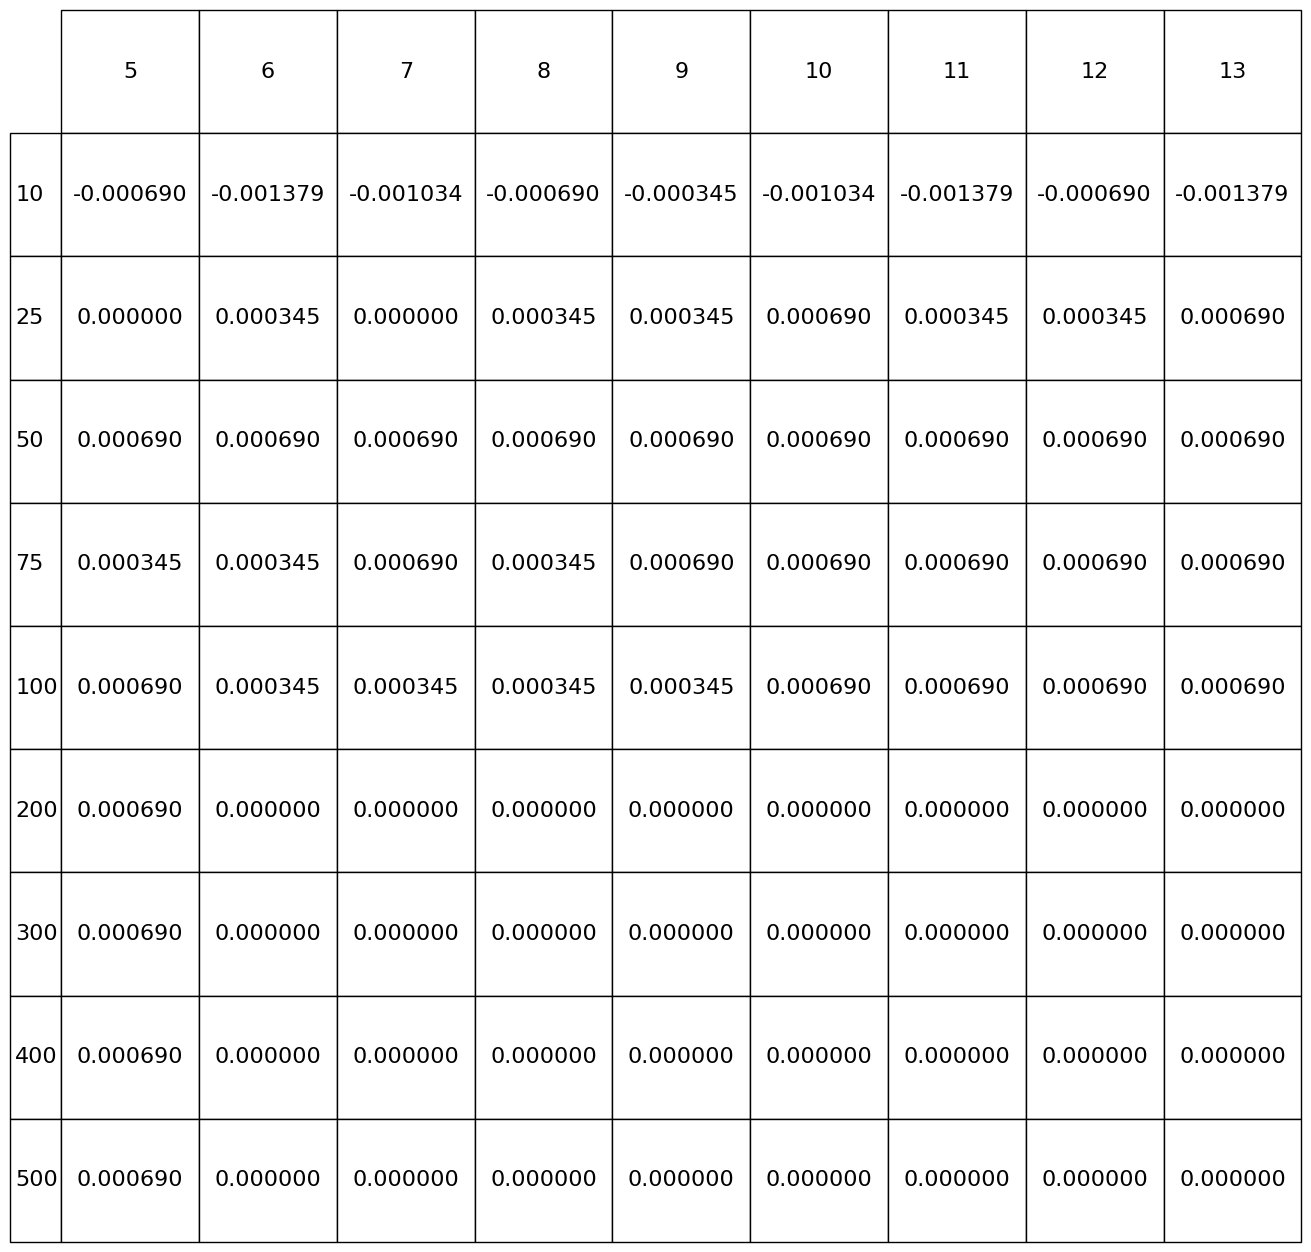

In [90]:
fig, ax1 = plt.subplots(figsize=(16, 16))
tab = ax1.table(rowLabels=total_estimators, colLabels=max_depth,cellText=cols,cellLoc='center', bbox = [0,0,1,1])
tab.set_fontsize(20)
ax1.axis('off')
#plt.savefig('roc_delta_only_lower_depth_neural_weights.jpg')

### Write results on file

In [129]:
results = pd.DataFrame()
estimators = []
depth = []
aucs = []
accuracies = []
for key in roc_delta_neural:
    estimators.append(key[0])
    depth.append(key[1])
    aucs.append(roc_delta_neural[key])
    accuracies.append(accuracy_delta_neural[key])

results['n_estimator'] = estimators
results['depth'] = depth
results['auc_delta'] = aucs
results['accuracy_delta'] = accuracies
results.to_csv('results_neural_weights.csv')

## Import saved data, plots and statistical test

In [2]:
datasets = ['accelerometer', 'vehicles', 'satellite', 'vowel', 'shuttle']
chosen_dataset = 2

In [3]:
total_estimators = [10,25,50,75,100,200,300,400,500]
depths = [5,6,7,8,9,10,11,12,13]
path = 'results/' + datasets[chosen_dataset] + '/results_neural_weights.csv'
df = pd.read_csv(path)
accuracy_delta_neural = {}
roc_delta_neural = {}
for i in range(df.shape[0]):
    accuracy_delta_neural[(int(df[i:i+1]['n_estimator'][i]),int(df[i:i+1]['depth'][i]))] = df[i:i+1]['accuracy_delta'][i]
    roc_delta_neural[(int(df[i:i+1]['n_estimator'][i]),int(df[i:i+1]['depth'][i]))] = df[i:i+1]['auc_delta'][i]

In [4]:
total_estimators = [10,25,50,75,100,200,300,400,500]
depths = [5,6,7,8,9,10,11,12,13]
path = 'results/' + datasets[chosen_dataset] + '/results_uniform_weights.csv'
df = pd.read_csv(path)
accuracy_delta_uniform = {}
roc_delta_uniform = {}
for i in range(df.shape[0]):
    accuracy_delta_uniform[(int(df[i:i+1]['n_estimator'][i]),int(df[i:i+1]['depth'][i]))] = df[i:i+1]['accuracy_delta'][i]
    roc_delta_uniform[(int(df[i:i+1]['n_estimator'][i]),int(df[i:i+1]['depth'][i]))] = df[i:i+1]['auc_delta'][i]

In [5]:
total_estimators = [10,25,50,75,100,200,300,400,500]
depths = [5,6,7,8,9,10,11,12,13]
path = 'results/' + datasets[chosen_dataset] + '/results_standard_case.csv'
df = pd.read_csv(path)
accuracy_delta_standard = {}
roc_delta_standard = {}
for i in range(df.shape[0]):
    accuracy_delta_standard[(int(df[i:i+1]['n_estimator'][i]),int(df[i:i+1]['depth'][i]))] = df[i:i+1]['accuracy_delta'][i]
    roc_delta_standard[(int(df[i:i+1]['n_estimator'][i]),int(df[i:i+1]['depth'][i]))] = df[i:i+1]['auc_delta'][i]

In [6]:
np.mean(list(accuracy_delta_neural.values())),np.mean(list(accuracy_delta_uniform.values())),np.mean(list(accuracy_delta_standard.values())),np.mean(list(roc_delta_neural.values())),np.mean(list(roc_delta_uniform.values())),np.mean(list(roc_delta_standard.values()))

(-0.003888888888888877,
 -0.02449999999999995,
 -0.004086419753086379,
 -0.002387267932847746,
 -0.004495903439871223,
 -0.0007790391905456009)

In [7]:
cols_neural = []
for n_estimators in total_estimators:
    row = []
    for depth in depths:
        row.append(accuracy_delta_neural[(n_estimators,depth)])
    cols_neural.append(row)

cols_neural = np.array(cols_neural)

In [8]:
cols_uniform = []
for n_estimators in total_estimators:
    row = []
    for depth in depths:
        row.append(accuracy_delta_uniform[(n_estimators,depth)])
    cols_uniform.append(row)

cols_uniform = np.array(cols_uniform)

In [9]:
cols_standard = []
for n_estimators in total_estimators:
    row = []
    for depth in depths:
        row.append(accuracy_delta_standard[(n_estimators,depth)])
    cols_standard.append(row)

cols_standard = np.array(cols_standard)

In [10]:
cols_neural2 = cols_neural.copy()

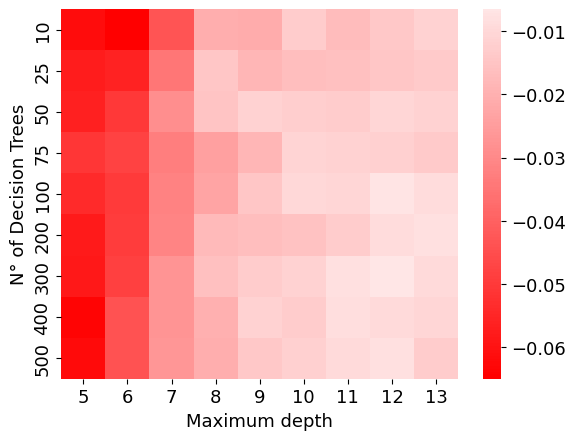

In [29]:
fig, ax = plt.subplots(1,1)

a = sns.heatmap(cols_uniform, center=0, cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256))
a.set_xticklabels(depths, fontsize=13)
a.set_yticklabels(total_estimators, fontsize=13)
#a.set(xlabel='Maximum depth', ylabel='N° of Decision Trees')
plt.xlabel('Maximum depth', fontsize=13)
plt.ylabel('N° of Decision Trees', fontsize=13)
a.set
a.collections[0].colorbar.ax.tick_params(labelsize=13)
plt.show()
fig.savefig('uniform_heatmap.pdf',format='pdf')

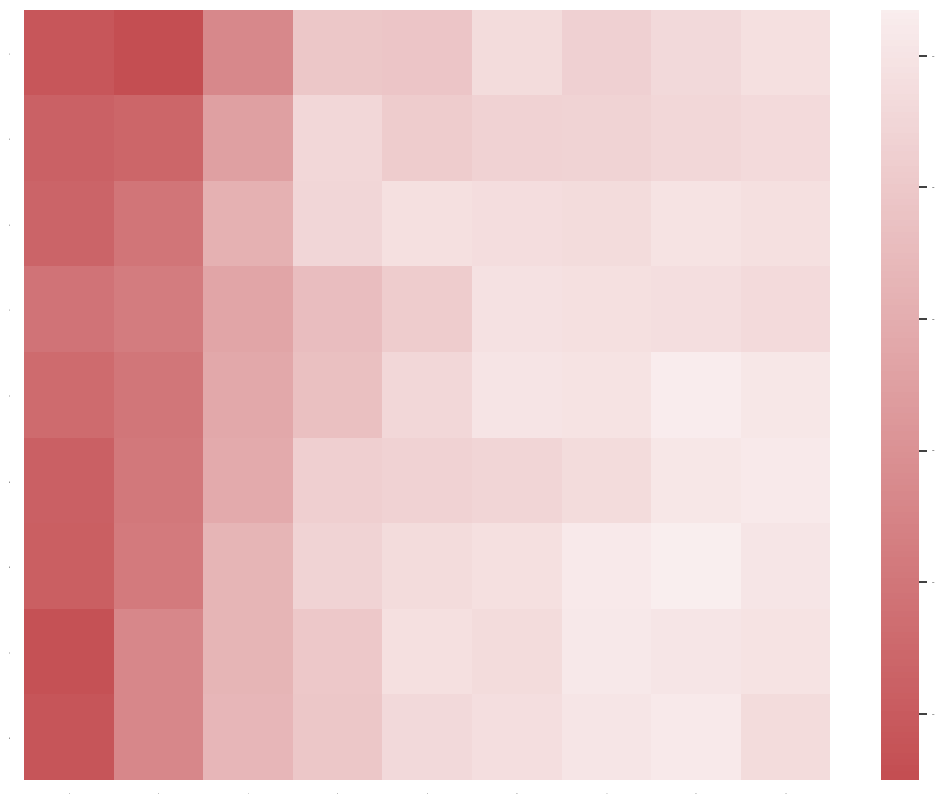

In [93]:
fig, axs = plt.subplots(1,1,figsize=(13,10))
sns.heatmap(cols_uniform, ax=axs, center=0, cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256) )
axs.set_xticklabels(depths)
axs.set_yticklabels(total_estimators)
plt.show()
fig.savefig('standard_heatmap.pdf',format='pdf')

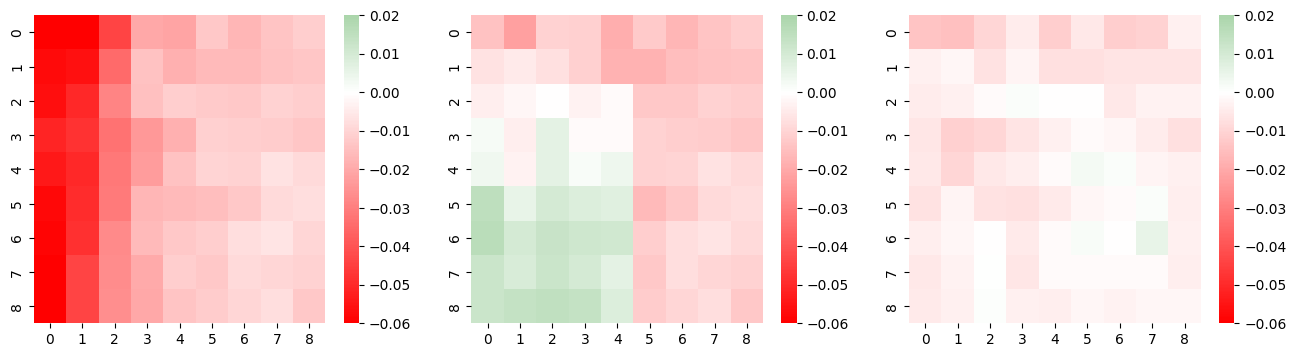

In [32]:
fig, axs = plt.subplots(1,3,figsize=(16,4))
sns.heatmap(cols_uniform, ax=axs[0], vmin=-0.06, vmax=0.02, center=-0.0, cmap=LinearSegmentedColormap.from_list('rg',["r", "w","g"], N=256) )
sns.heatmap(cols_neural, ax=axs[1], vmin=-0.06, vmax=0.02, center=-0.0, cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256) )
sns.heatmap(cols_standard, ax=axs[2], vmin=-0.06, vmax=0.02, center=-0.0, cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256) )
plt.show()
#fig.savefig('heatmap_comparison.jpg')

In [31]:
cols = []
for n_estimators in total_estimators:
    row = []
    for depth in depths:
        row.append(roc_delta[(n_estimators,depth)])
    cols.append(row)

cols = np.array(cols)

<Axes: >

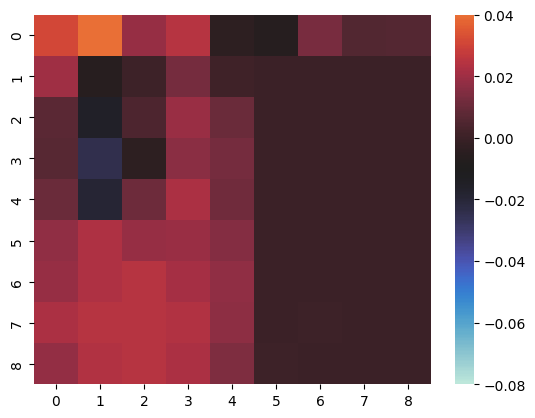

In [33]:
sns.heatmap(cols,center = -0.01, vmin=-0.08, vmax=0.04)

In [ ]:
values_roc = []
values_acc = []
for i,n_estimators in enumerate(total_estimators):
    for j,depth in enumerate(depths):
       if j<i:
            values_roc.append(roc_delta[(n_estimators,depth)])
            values_acc.append(accuracy_delta[(n_estimators,depth)])

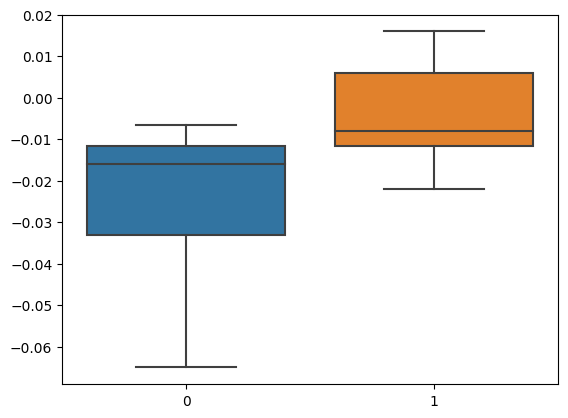

In [139]:
b_plot = sns.boxplot([list(accuracy_delta.values()), list(accuracy_delta_neural.values())])
fig = b_plot.get_figure()
fig.savefig('box_plot_roc_comparison.jpg')

In [137]:
from scipy.stats import kstest
kstest(list(roc_delta_neural.values()),list(roc_delta.values()))

KstestResult(statistic=0.30864197530864196, pvalue=0.0008246996527296863, statistic_location=-0.001651586890703327, statistic_sign=-1)

## Hardware transormation

In [ ]:
class NOInst:
    def __init__(self, nodeRA, attr_id, threhsold, lctype, lcinfo, rctype, rcinfo):
        self.nodeRA = nodeRA
        self.attr_id = attr_id
        self.threhsold = threhsold
        self.lctype = lctype
        self.lcinfo = lcinfo
        self.rctype = rctype
        self.rcinfo = rcinfo
        
class Node:
    def __init__(self, nodeRA, ram_id, left_child, right_child, attr_id, threshold):
        self.nodeRA = nodeRA
        self.ram_id = ram_id
        self.left_child = left_child
        self.right_child = right_child
        self.attr_id = attr_id
        self.threshold = threshold

In [ ]:
def transform_into_instructions(classifier, N, M): #N max NOinsts in one BRAM, M maximum available BRAMs
    FLInsts = np.zeros(M)
    NOInsts = []
    current_id = 0
    for i, estimator in enumerate(classifier.estimators_):
        nodes = {}
        FLInsts[current_id] = 1
        this_level_nodes = []
        next_level_nodes = [0]
        for j in range(estimator.tree_.max_depth):
            this_level_nodes = next_level_nodes.copy()
            next_level_nodes = []
            needed_bram = int(len(this_level_nodes)/(N+1)) + 1
            for i,node in enumerate(this_level_nodes):
                if estimator.tree_.children_left[node] != -1 and estimator.tree_.children_right[node] != -1:
                    index = node
                    ram_id = current_id + int(i/N)
                    nodeRA = i%N
                    left_children = estimator.tree_.children_left[node]
                    right_children = estimator.tree_.children_right[node]
                    attr_id = estimator.tree_.feature[node]
                    threshold = estimator.tree_.threshold[node]
                    nodes[node] = Node(nodeRA,ram_id,left_children,right_children,attr_id,threshold)
                    next_level_nodes.append(estimator.tree_.children_left[node])
                    next_level_nodes.append(estimator.tree_.children_right[node])
            current_id += needed_bram
        print(nodes)
        for node in nodes.values():
            if estimator.tree_.feature[node.left_child] < 0:
                left_child_type = 0
                left_child_info = np.argmax(estimator.tree_.value[node.left_child,0])
            else:
                left_child_type = nodes[node.left_child].ram_id - node.ram_id
                left_child_info = nodes[node.left_child].nodeRA
            if estimator.tree_.feature[node.right_child] < 0:
                right_child_type = 0
                right_child_info = np.argmax(estimator.tree_.value[node.right_child,0])
            else:
                right_child_type = nodes[node.right_child].ram_id - node.ram_id
                right_child_info = nodes[node.right_child].nodeRA
            NOInsts.append(NOInst(node.nodeRA,node.attr_id,node.threshold,left_child_type,left_child_info,right_child_type,right_child_info))
    
    return FLInsts, NOInsts

In [ ]:
FLInsts, NOInsts = transform_into_instructions(classifier,100,100000)
FLInsts = FLInsts[:len(NOInsts)]

In [ ]:
len(FLInsts)

In [ ]:
for i,inst in enumerate(NOInsts):
    print(f"instruction {i}")
    print(inst.__dict__)

In [ ]:
FLInsts

## Tests for DATE, unbalanced MDRFC

In [1]:
import numpy as np
import pandas as pd
import sys
import logging
logging.getLogger('tensorflow').disabled = True
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from MultiDepthRandomForest import MultiDepthRandomForestClassifier, MultiDepthNeuralRandomForestClassifier
from datasets import import_accelerometer, import_vehicles, import_vowel, import_satellite, import_shuttle, import_sonar
import tensorflow as tf
from sklearn.metrics import roc_auc_score
import seaborn as sns
from  matplotlib.colors import LinearSegmentedColormap
tfk = tf.keras
tfkl = tfk.layers

2024-09-06 09:39:38.853901: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Casi di interesse:
### 7, 50, [10,10,10,11,9]
### 7, 75, [15,15,15,21,9]
### 7, 100, [20,20,20,22,18]
### 7, 100, [20,20,20,31,9]
### 5, 700, [140,140,140,208,72]
### 5, 700, [140,140,140,172,108]

In [2]:
max_depths = [7,7,7,7,5,5]
n_estimators = [50,75,100,100,700,700]
distributions = [[10,10,10,11,9],[15,15,15,21,9],[20,20,20,22,18],[20,20,20,31,9],[140,140,140,208,72],[140,140,140,172,108]]

In [20]:
dic = {}
dic['dataset'] = []
dic['max_depth'] = []
dic['n_trees'] = []
dic['distr'] = []
dic['acc'] = []
dic['auc'] = []
X_train, X_val, X_test, Y_train, Y_val, Y_test = import_shuttle()
X_train = X_train[Y_train!=6]
Y_train = Y_train[Y_train!=6]
for i in range(len(max_depths)):
    print(max_depths[i], n_estimators[i], distributions[i])
    neural_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i],random_state=3)
    neural_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc1 = neural_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc1 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Balanced model: ", acc1, auc1)

    neural_unbalanced_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i], depth_distribution=distributions[i], random_state=3)
    neural_unbalanced_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc2 = neural_unbalanced_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc2 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Unbalanced model: ", acc2, auc2)

    print("Differences: ", acc2 - acc1, auc2 - auc1)

    dic['dataset'].append('shuttle')
    dic['max_depth'].append(max_depths[i])
    dic['n_trees'].append(n_estimators[i])
    dic['distr'].append(distributions[i])
    dic['acc'].append(acc2-acc1)
    dic['auc'].append(auc2-auc1)

X_train, X_val, X_test, Y_train, Y_val, Y_test = import_accelerometer()
for i in range(len(max_depths)):
    print(max_depths[i], n_estimators[i], distributions[i])
    neural_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i],random_state=3)
    neural_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc1 = neural_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc1 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Balanced model: ", acc1, auc1)

    neural_unbalanced_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i], depth_distribution=distributions[i], random_state=3)
    neural_unbalanced_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc2 = neural_unbalanced_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc2 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Unbalanced model: ", acc2, auc2)

    print("Differences: ", acc2 - acc1, auc2 - auc1)

    dic['dataset'].append('shuttle')
    dic['max_depth'].append(max_depths[i])
    dic['n_trees'].append(n_estimators[i])
    dic['distr'].append(distributions[i])
    dic['acc'].append(acc2-acc1)
    dic['auc'].append(auc2-auc1)

X_train, X_val, X_test, Y_train, Y_val, Y_test = import_satellite()
Y_train[Y_train!=7] -= 1
Y_val[Y_val!=7] -= 1
Y_test[Y_test!=7] -= 1
Y_train[Y_train==7] -= 2
Y_val[Y_val==7] -= 2
Y_test[Y_test==7] -= 2
for i in range(len(max_depths)):
    print(max_depths[i], n_estimators[i], distributions[i])
    neural_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i],random_state=3)
    neural_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc1 = neural_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc1 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Balanced model: ", acc1, auc1)

    neural_unbalanced_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i], depth_distribution=distributions[i], random_state=3)
    neural_unbalanced_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc2 = neural_unbalanced_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc2 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Unbalanced model: ", acc2, auc2)

    print("Differences: ", acc2 - acc1, auc2 - auc1)

    dic['dataset'].append('shuttle')
    dic['max_depth'].append(max_depths[i])
    dic['n_trees'].append(n_estimators[i])
    dic['distr'].append(distributions[i])
    dic['acc'].append(acc2-acc1)
    dic['auc'].append(auc2-auc1)

X_train, X_val, X_test, Y_train, Y_val, Y_test = import_vehicles()
for i in range(len(max_depths)):
    print(max_depths[i], n_estimators[i], distributions[i])
    neural_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i],random_state=3)
    neural_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc1 = neural_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc1 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Balanced model: ", acc1, auc1)

    neural_unbalanced_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i], depth_distribution=distributions[i], random_state=3)
    neural_unbalanced_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc2 = neural_unbalanced_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc2 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Unbalanced model: ", acc2, auc2)

    print("Differences: ", acc2 - acc1, auc2 - auc1)

    dic['dataset'].append('shuttle')
    dic['max_depth'].append(max_depths[i])
    dic['n_trees'].append(n_estimators[i])
    dic['distr'].append(distributions[i])
    dic['acc'].append(acc2-acc1)
    dic['auc'].append(auc2-auc1)

X_train, X_val, X_test, Y_train, Y_val, Y_test = import_vowel()
for i in range(len(max_depths)):
    print(max_depths[i], n_estimators[i], distributions[i])
    neural_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i],random_state=3)
    neural_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc1 = neural_classifier.score(X_test, Y_test)
    Y_pred = neural_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc1 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Balanced model: ", acc1, auc1)

    neural_unbalanced_classifier = MultiDepthNeuralRandomForestClassifier(total_estimators=n_estimators[i],min_depth=max_depths[i]-4,max_depth=max_depths[i], depth_distribution=distributions[i], random_state=3)
    neural_unbalanced_classifier.fit(X_train, Y_train, X_val, Y_val)
    acc2 = neural_unbalanced_classifier.score(X_test, Y_test)
    Y_pred = neural_unbalanced_classifier.predict_proba(X_test)
    Y_pred = Y_pred/np.sum(Y_pred,axis=1).reshape(Y_pred.shape[0],1)
    auc2 = roc_auc_score(Y_test, Y_pred, multi_class="ovo")

    print("Unbalanced model: ", acc2, auc2)

    print("Differences: ", acc2 - acc1, auc2 - auc1)

    dic['dataset'].append('shuttle')
    dic['max_depth'].append(max_depths[i])
    dic['n_trees'].append(n_estimators[i])
    dic['distr'].append(distributions[i])
    dic['acc'].append(acc2-acc1)
    dic['auc'].append(auc2-auc1)

7 50 [10, 10, 10, 11, 9]
10
10
10
10
10
Balanced model:  0.9989655172413793 0.9072858958690848
10
10
10
11
9
Unbalanced model:  0.9989655172413793 0.9072858958690848
Differences:  0.0 0.0
7 75 [15, 15, 15, 21, 9]
15
15
15
15
15
Balanced model:  0.9989655172413793 0.8950487012987014
15
15
15
21
9
Unbalanced model:  0.9993103448275862 0.8950487012987014
Differences:  0.00034482758620690834 0.0
7 100 [20, 20, 20, 22, 18]
20
20
20
20
20
Balanced model:  0.9993103448275862 0.8946698313601477
20
20
20
22
18
Unbalanced model:  0.9993103448275862 0.8946698313601477
Differences:  0.0 0.0
7 100 [20, 20, 20, 31, 9]
20
20
20
20
20
Balanced model:  0.9993103448275862 0.8946698313601477
20
20
20
31
9
Unbalanced model:  0.9993103448275862 0.8946698313601477
Differences:  0.0 0.0
5 700 [140, 140, 140, 208, 72]
140
140
140
140
140
Balanced model:  0.9989655172413793 0.9194384183850172
140
140
140
208
72
Unbalanced model:  0.9989655172413793 0.9194384183850172
Differences:  0.0 0.0
5 700 [140, 140, 140,

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/numpy/lib/function_base.py:5339: ComplexWarning: Casting complex values to real discards the imaginary part
  values = array(values, copy=False, ndmin=arr.ndim, dtype=arr.dtype)


7 50 [10, 10, 10, 11, 9]
10
10
10
10
10
Balanced model:  0.7622739018087855 0.8728424338859829
10
10
10
11
9
Unbalanced model:  0.7571059431524548 0.8728424338859829
Differences:  -0.0051679586563306845 0.0
7 75 [15, 15, 15, 21, 9]
15
15
15
15
15
Balanced model:  0.7700258397932817 0.8716138638046315
15
15
15
21
9
Unbalanced model:  0.7648578811369509 0.8716138638046315
Differences:  -0.0051679586563307955 0.0
7 100 [20, 20, 20, 22, 18]
20
20
20
20
20
Balanced model:  0.7855297157622739 0.8889218290892804
20
20
20
22
18
Unbalanced model:  0.7751937984496124 0.8889218290892804
Differences:  -0.01033591731266148 0.0
7 100 [20, 20, 20, 31, 9]
20
20
20
20
20
Balanced model:  0.7855297157622739 0.8889218290892804
20
20
20
31
9
Unbalanced model:  0.7648578811369509 0.8889218290892804
Differences:  -0.02067183462532307 0.0
5 700 [140, 140, 140, 208, 72]
140
140
140
140
140
Balanced model:  0.7545219638242894 0.8678719589990155
140
140
140
208
72
Unbalanced model:  0.7441860465116279 0.8678719

/Users/alessandroverosimile/Documents/Polimi/NecstCamp/NL2/MultiDepthRF/datasets.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'][df['sex']=='Male'] = 1
/Users/alessandroverosimile/Documents/Polimi/NecstCamp/NL2/MultiDepthRF/datasets.py:127: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'][df['sex']=='Female'] = 0


Balanced model:  0.8383838383838383 0.9811346504132097
10
10
10
11
9
Unbalanced model:  0.8181818181818182 0.9812682028432242
Differences:  -0.02020202020202011 0.00013355243001456074
7 75 [15, 15, 15, 21, 9]
15
15
15
15
15
Balanced model:  0.8434343434343434 0.9860656544128412
15
15
15
21
9
Unbalanced model:  0.8434343434343434 0.9862696117150507
Differences:  0.0 0.00020395730220945651
7 100 [20, 20, 20, 22, 18]
20
20
20
20
20
Balanced model:  0.8636363636363636 0.9881963274482456
20
20
20
22
18
Unbalanced model:  0.8585858585858586 0.988325433407488
Differences:  -0.005050505050505083 0.00012910595924242596
7 100 [20, 20, 20, 31, 9]
20
20
20
20
20
Balanced model:  0.8636363636363636 0.9881963274482456
20
20
20
31
9
Unbalanced model:  0.8535353535353535 0.9876269651695909
Differences:  -0.010101010101010166 -0.0005693622786546726
5 700 [140, 140, 140, 208, 72]
140
140
140
140
140
Balanced model:  0.7828282828282829 0.9803204372353989
140
140
140
208
72
Unbalanced model:  0.7878787878

In [22]:
df.to_csv('latency_acc_trade_off')